In [1]:
import os
import uuid
import shutil
#import pylatex
import pandas as pd
import lightkurve as lk 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

from datetime import datetime
from tqdm.notebook import tqdm
from multiprocessing import cpu_count, Pool
#from pylatex.section import Chapter, Subsection
#from pylatex import Document, Section, Figure, NoEscape, Command

%run pipeline.ipynb

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

In [2]:
coltypes={'ID':str,'TIC':str,'gaiadr3_source_id':str,'epic_id':str,'Score1':'Int64','Flare1':'Int64',
          'Shelf1':'Int64','Evolution1':'Int64','Score2':'Int64','Flare2':'Int64','Shelf2':'Int64','Evolution2':'Int64'}

In [3]:
lctable=pd.read_csv('lcscoresandchecker.csv',dtype=coltypes)

In [4]:
lctable1=lctable[['pop_id','lcname','idtype','ID','secorcamp','LC_author','cadence','fluxamplitude',
                 'TIC','gaiadr3_source_id','epic_id','per','group','age_Myr','disco_paper',
                 'paper_author','year','Score1','Flare1','Shelf1','Evolution1','Notes1','complex_status1']]
lctable2=lctable[['pop_id','lcname','idtype','ID','secorcamp','LC_author','cadence','fluxamplitude',
                 'TIC','gaiadr3_source_id','epic_id','per2','group','age_Myr','disco_paper',
                 'paper_author','year','Score2','Flare2','Shelf2','Evolution2','Notes2','complex_status2']]
lctable1['per_col']='one'
lctable2['per_col']='two'
lctable1.dropna(subset=['Score1'],inplace=True)
lctable2.dropna(subset=['Score2'],inplace=True)
lctable1.rename(columns={'Score1':'Score','Flare1':'Flare','Shelf1':'Shelf',
                         'Evolution1':'Evolution','Notes1':'Notes',
                         'complex_status1':'complex_status'},inplace=True)
lctable2.rename(columns={'per2':'per','Score2':'Score','Flare2':'Flare','Shelf2':'Shelf',
                         'Evolution2':'Evolution','Notes2':'Notes',
                         'complex_status2':'complex_status'},inplace=True)
lctablecomb=pd.concat([lctable1,lctable2],ignore_index=True)

In [5]:
def complexovertime(scoreseries):
    scorearray=scoreseries.to_numpy()
    scores=np.unique(scorearray)
    if 0 in scores and 1 in scores and 2 in scores:
        return 'All 3 scores'
    elif 1 in scores and 2 in scores:
        return '1 and 2'
    elif 0 in scores and 1 in scores:
        return '0 and 1'
    elif 0 in scores and 2 in scores:
        return '0 and 2'
    elif 2 in scores:
        return '2 only'
    elif 1 in scores:
        return '1 only'
    elif 0 in scores:
        return '0 only'
    elif 9 in scores:
        return 'all bad'
    else:
        return 'error'

In [6]:
def scorestr(scoreseries):
    scorearray=scoreseries.to_numpy()
    scorestr=''
    for score in scorearray:
        scorestr+=str(score)+' '
    return scorestr

In [7]:
grouped=lctablecomb.groupby(['pop_id','per']).agg(per_col=('per_col','first'),
                                                    scoreagg=('Score',complexovertime),
                                                  scorelist=('Score',scorestr),
                                                  disco_paper=('disco_paper','first'),
                                                  seclist=('secorcamp',scorestr)).reset_index()

In [8]:
grouped = grouped.sort_values(['pop_id', 'per_col']).reset_index(drop=True)

In [9]:
plotids = pd.DataFrame({
    "pop_id": pd.Series(dtype="int64")
})

In [10]:
id_list=[49,71,72,74,75,84,96,105,108,110,121,122,123,133,149,162,166,170,179,180,198,202,207,210,211]

In [11]:
plotids=grouped[np.logical_and(grouped['pop_id'].isin(id_list),np.logical_or(np.logical_or(grouped.scoreagg=='0 and 1',
                                                                  grouped.scoreagg=='0 and 2'),
                                                      grouped.scoreagg=='All 3 scores')) ]

In [12]:
plotids["sector1"] = 0
plotids["sector2"] = 0
plotids = plotids.astype({"sector1": "int64", "sector2": "int64"})

In [13]:
plotids.loc[plotids["pop_id"] == 49, ["sector1", "sector2"]] = [11, 64]
plotids.loc[plotids["pop_id"] == 71, ["sector1", "sector2"]] = [43, 70]
plotids.loc[plotids["pop_id"] == 75, ["sector1", "sector2"]] = [4, 30]
plotids.loc[plotids["pop_id"] == 84, ["sector1", "sector2"]] = [44, 59]
plotids.loc[plotids["pop_id"] == 96, ["sector1", "sector2"]] = [2, 3]
plotids.loc[plotids["pop_id"] == 105, ["sector1", "sector2"]] = [12, 94]
plotids.loc[plotids["pop_id"] == 108, ["sector1", "sector2"]] = [10, 64]
plotids.loc[plotids["pop_id"] == 121, ["sector1", "sector2"]] = [11, 38]
plotids.loc[plotids["pop_id"] == 122, ["sector1", "sector2"]] = [11, 38]
plotids.loc[plotids["pop_id"] == 123, ["sector1", "sector2"]] = [11, 65]
plotids.loc[plotids["pop_id"] == 133, ["sector1", "sector2"]] = [39, 91]
plotids.loc[plotids["pop_id"] == 149, ["sector1", "sector2"]] = [12,91]
plotids.loc[plotids["pop_id"] == 162, ["sector1", "sector2"]] = [38,65]
plotids.loc[plotids["pop_id"] == 166, ["sector1", "sector2"]] = [38,65]
plotids.loc[plotids["pop_id"] == 170, ["sector1", "sector2"]] = [38,65]
plotids.loc[plotids["pop_id"] == 179, ["sector1", "sector2"]] = [39,66]
plotids.loc[plotids["pop_id"] == 180, ["sector1", "sector2"]] = [12,39]
plotids.loc[plotids["pop_id"] == 198, ["sector1", "sector2"]] = [11, 38]
plotids.loc[plotids["pop_id"] == 202, ["sector1", "sector2"]] = [30,69]
plotids.loc[plotids["pop_id"] == 207, ["sector1", "sector2"]] = [31,32]
plotids.loc[plotids["pop_id"] == 211, ["sector1", "sector2"]] = [43,44]

In [14]:
plotids = plotids.loc[~((plotids["pop_id"] == 108) & (plotids["per_col"] == "two"))].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 162) & (plotids["per_col"] == "one"))].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 210) & (plotids["per_col"] == "two"))].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 72) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 74) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 110) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 210) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 49) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 71) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 84) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 96) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 133) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 179) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 198) )].reset_index(drop=True)
plotids = plotids.loc[~((plotids["pop_id"] == 211) )].reset_index(drop=True)


In [15]:
plotids['one']=1

In [16]:
plotids

,pop_id,per,per_col,scoreagg,scorelist,disco_paper,seclist,sector1,sector2,one
0,75,0.663210,one,0 and 2,2 2 0 0 2,Popinchalk_2023,3 4 30 31 97,4,30,1
1,105,0.453333,one,All 3 scores,1 1 1 1 0 1 1 1 0 2 2 0 1 2 1 1 2 2 0 1 1 2 2 ...,Zhan_2019,1 2 3 4 5 6 7 8 9 10 11 12 13 27 28 29 30 31 3...,12,94,1
2,108,0.392917,one,All 3 scores,2 2 2 1 2 2 2 1 1 0 9 1 0,Bouma_2024,8 9 10 35 36 37 61 62 63 64 88 89 90,10,64,1
3,121,0.585417,one,0 and 2,0 2 2,Bouma_2024,11 38 65,11,38,1
4,122,1.159583,two,0 and 2,0 2 2,Stauffer_2021,11 38 65,11,38,1
5,123,2.112500,two,0 and 2,2 0 0,Bouma_2024,11 38 65,11,65,1
6,149,0.572700,one,All 3 scores,9 9 0 1 2,Rebull_2018,2 2 12 39 91,12,91,1
7,162,2.811100,two,All 3 scores,0 1 2 1 0,Rebull_2022,11 37 38 64 65,38,65,1
8,166,0.518300,one,All 3 scores,0 2 1 0,Rebull_2022,11 38 64 65,38,65,1
9,170,1.386800,one,All 3 scores,1 2 0,Rebull_2022,11 38 65,38,65,1


In [17]:
def double_lc(pop_id,sector1,sector2,period):
    row1=lctable[np.logical_and(lctable.pop_id==pop_id,lctable.secorcamp==sector1)]
    name1=row1.lcname.values[0]
    lc1=get_lc_string(name1)
    row2=lctable[np.logical_and(lctable.pop_id==pop_id,lctable.secorcamp==sector2)]
    name2=row2.lcname.values[0]
    lc2=get_lc_string(name2)

    if row1.LC_author.values[0]=='FFI':
        lc1.flux=lc1.flux+1
    else:
        lc1=lc1.normalize()
    if row2.LC_author.values[0]=='FFI':
        lc2.flux=lc2.flux+1
    else:
        lc2=lc2.normalize()

    if period=='one':
        period=u.Quantity(row1.per.values[0],u.d)
    else:
        period=u.Quantity(row1.per2.values[0],u.d)
    bintime=u.Quantity(period/200,u.s)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
    epoch_time=subgraph_phaselc(lc1,period=period,ax=ax1,bintime=bintime,showperiod=False,returnepoch=True)
    subgraph_phaselc(lc2,period=period,ax=ax2,bintime=bintime,showperiod=False,epoch_time=epoch_time)
    ax1.set_ylabel('')
    ax2.set_ylabel('')
    ax1.set_xlabel('')
    ax2.set_xlabel('')
    ax1.set_xticklabels([])
    ax2.set_xticklabels([])
    ax1.set_xticks([])
    ax2.set_xticks([])
    ax1.tick_params(direction='in')
    ax2.tick_params(direction='in')
    plt.subplots_adjust(wspace=0)
    ax1.set_title(f'Sector {sector1}')
    ax2.set_title(f'Sector {sector2}')
    #fig.suptitle(f'{pop_id}, TIC {row1.TIC.values[0]}, {period}',y=0.94)
    fig.suptitle(f'TIC {row1.TIC.values[0]}, {period}, {pop_id}',y=0.94)
    #fig.savefig(f'multiplots/comparison/{pop_id}.png',bbox_inches='tight')
    return fig

In [18]:
fig_images = []

In [19]:
for index, row in plotids.iterrows():
    fig = double_lc(row.pop_id, row.sector1, row.sector2, row.per_col) 
    fig.tight_layout()
    fig.set_dpi(300)
    fig.canvas.draw()
    img = np.array(fig.canvas.renderer.buffer_rgba())
    fig_images.append(img)
    plt.close(fig)

In [20]:
plt.close('all')

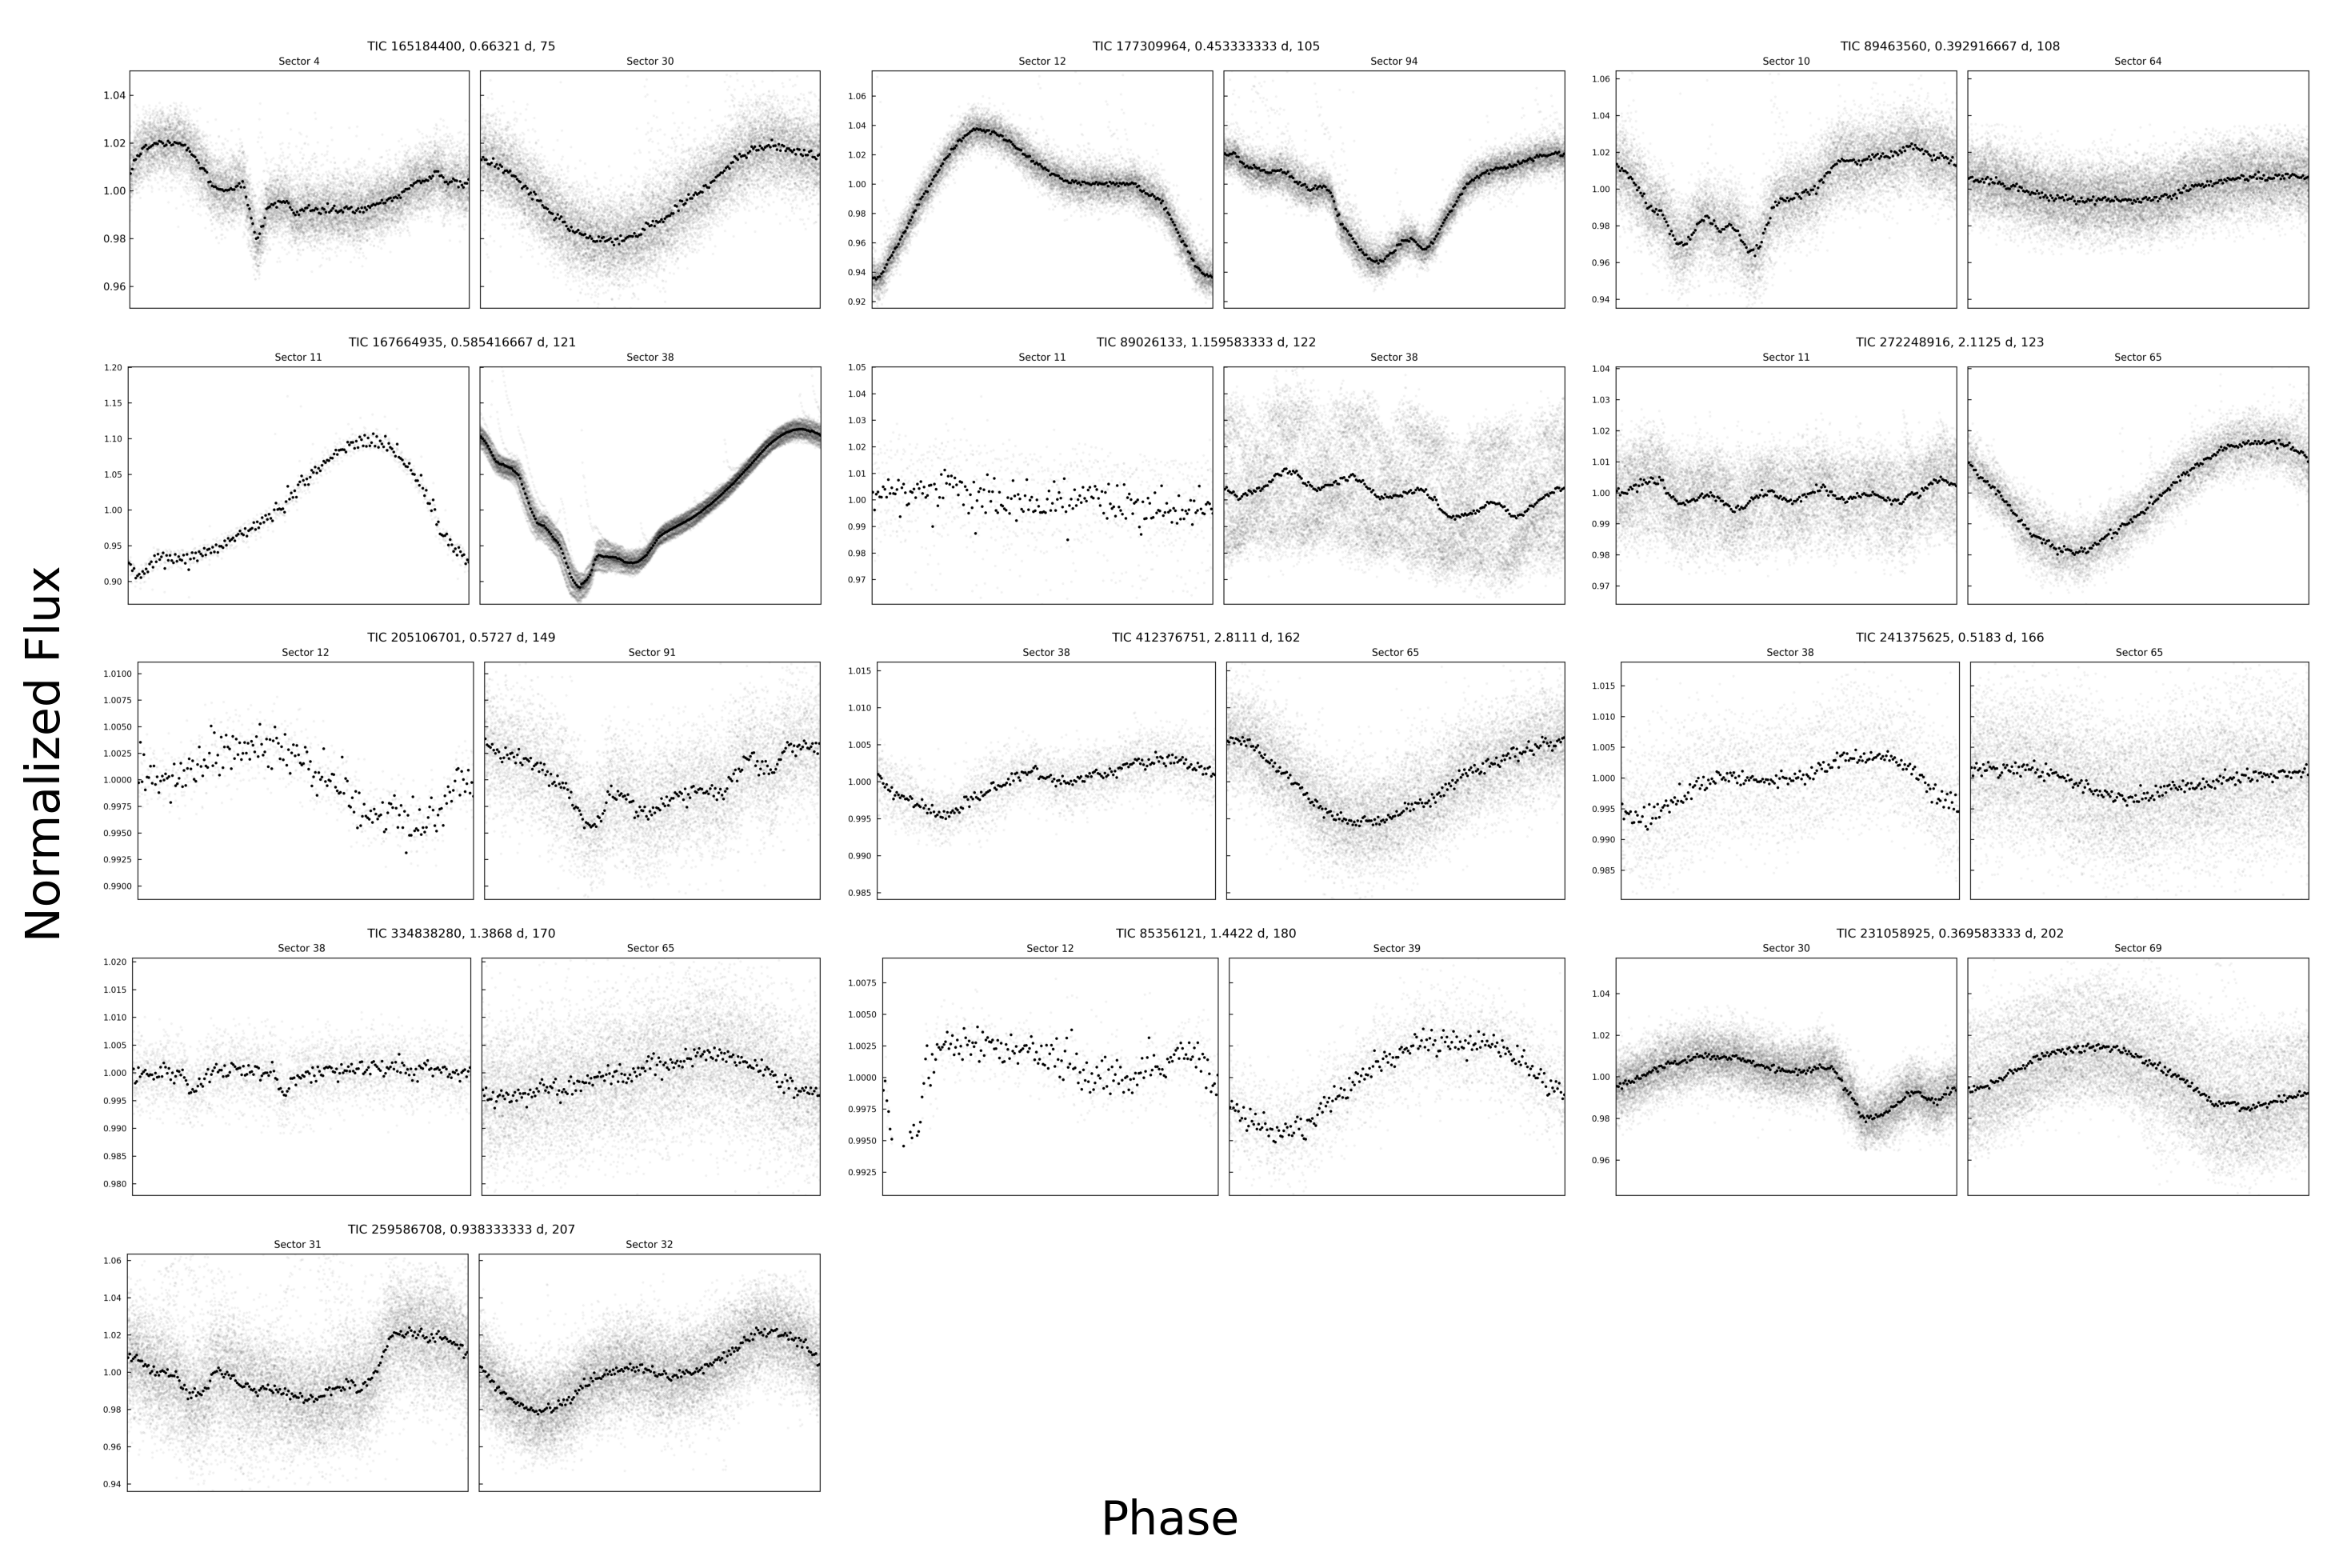

In [21]:
# Step 2: Decide grid size
ncols = 3
nrows = int(np.ceil(np.sum(plotids.one)/ncols))

# Compute aspect ratio of images
img_h, img_w, _ = fig_images[0].shape
aspect = img_h / img_w 

# Create master figure
fig = plt.figure(figsize=(ncols*4, nrows*4*aspect),dpi=300)
gs = gridspec.GridSpec(nrows, ncols, wspace=0.0, hspace=0.0)

for i, img in enumerate(fig_images):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(img)
    ax.axis('off')

fig.text(0.5, 0.1, "Phase", ha='center', va='center', fontsize=14)
fig.text(0.11, 0.5, "Normalized Flux", ha='center', va='center', rotation='vertical', fontsize=14)

plt.show()
fig.savefig('multiplots/comparison/complexnotmegaplot.png',bbox_inches='tight')